

### Scripts for mito width stats, saliency maps, PCA-RGB, and retrieval viz. Run top to bottom.

### Mitochondria width distribution

Before extracting patches, we need to pick a patch size. since mitochondria vary in size, patches should be large enough to contain whole organelle. This script scans all instance masks, computes the max extent (larger of bbox height/width) per mitochondria, and writes the distribution to `results/mito_widths.json`. Eyeball the distribution to picka a percentile to inform `PATCH_SIZE` in `extract_mito_patches.py`.

In [4]:
# Scans label masks, computes max extent per mitochondrion, writes ../results/mito_widths.json
# (paths are relative to notebooks/)
!python ../scripts/mito_width_stats.py --data-dir ../data/em_slices -o ../results/mito_widths.json

^C


90th percentile of mitochondria max dimension: 370.8
80th percentile of mitochondria max dimension: 230.6


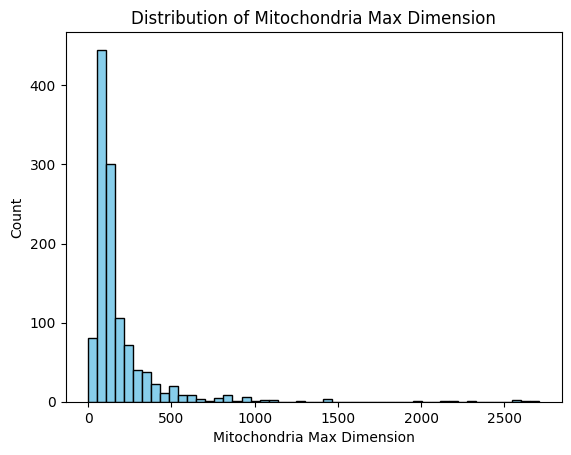

In [ ]:
## PLOT THE DISTRIBUTION OF MITO MAX DIM 
import json
import matplotlib.pyplot as plt
import numpy as np


with open("../results/mito_widths.json", "r") as f:
    data = json.load(f)
widths = data["widths"]

# print the percentiles
p90 = np.percentile(widths, 90)
print(f"90th percentile of mitochondria max dimension: {p90:.1f}")
p80 = np.percentile(widths, 80)
print(f"80th percentile of mitochondria max dimension: {p80:.1f}")


# histogram
plt.hist(widths, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Mitochondria Max Dimension")
plt.ylabel("Count")
plt.title("Distribution of Mitochondria Max Dimension")
plt.show()


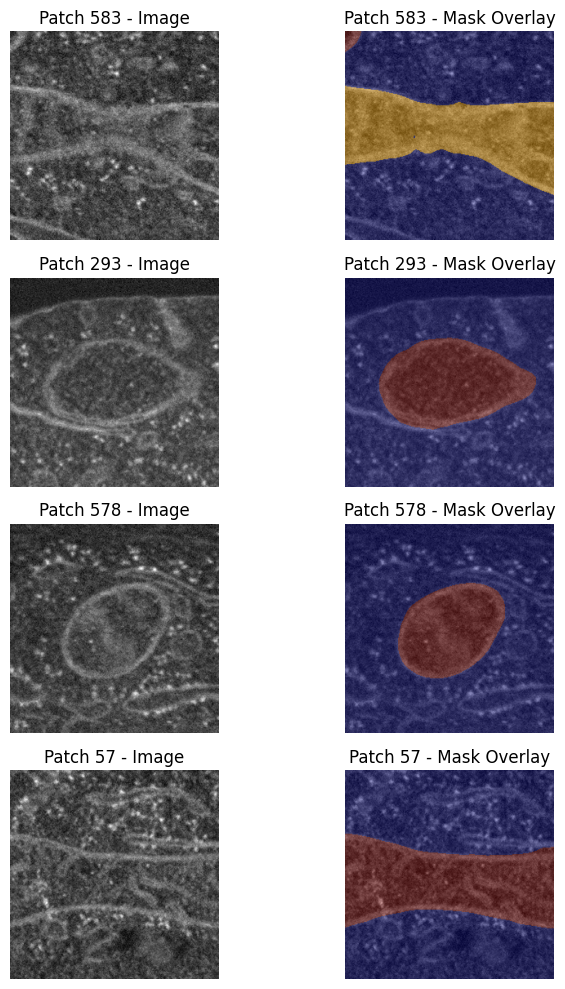

In [ ]:
## VISUALIZE PATCHES AND MASK OVERLAY 
import numpy as np
import matplotlib.pyplot as plt

# Relative to notebooks/
npz_path = "../data/patches/jrc_hela2_mito_dataset_256.npz"
with np.load(npz_path, allow_pickle=True) as d:
    images = d["images"]
    masks = d["masks"]
    metadata = d["metadata"]

num_examples = min(4, images.shape[0])

# Randomly shuffle indices and pick num_examples
perm = np.random.permutation(images.shape[0])
selected_idx = perm[:num_examples]

fig, axes = plt.subplots(num_examples, 2, figsize=(8, 2.5 * num_examples))

for row, idx in enumerate(selected_idx):
    ax_img = axes[row, 0]
    ax_mask = axes[row, 1]

    ax_img.imshow(images[idx], cmap="gray")
    ax_img.set_title(f"Patch {idx} - Image")
    ax_img.axis("off")

    ax_mask.imshow(images[idx], cmap="gray")
    ax_mask.imshow(masks[idx], cmap="jet", alpha=0.4)
    ax_mask.set_title(f"Patch {idx} - Mask Overlay")
    ax_mask.axis("off")

plt.tight_layout()
plt.show()

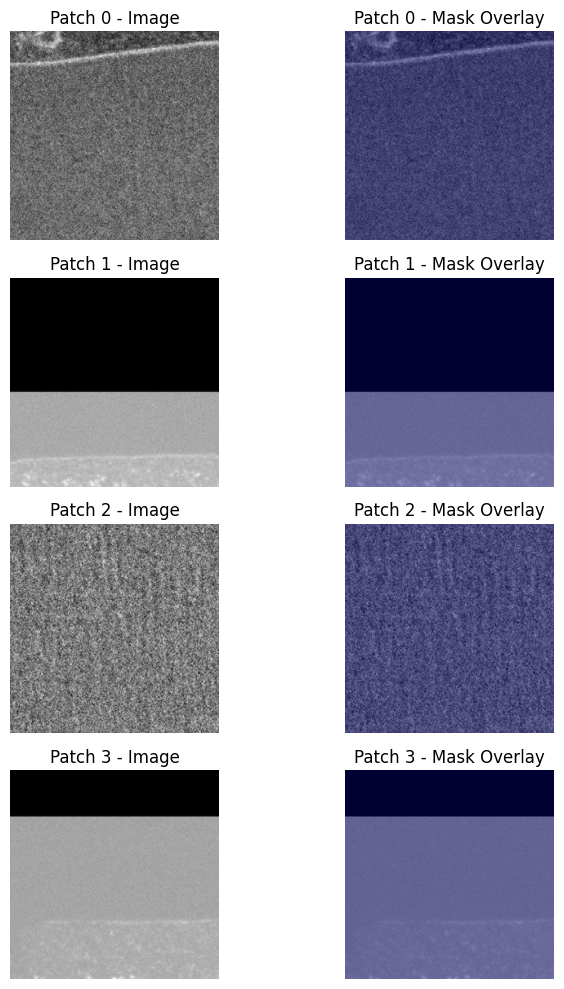

In [ ]:
## VISUALIZE PATCHES AND MASK OVERLAY FOR BACKGROUND PATCHES
import numpy as np
import matplotlib.pyplot as plt

# Relative to notebooks/
npz_path = "../data/patches/jrc_hela2_background_256.npz"
with np.load(npz_path, allow_pickle=True) as d:
    images = d["images"]
    masks = d["masks"]
    metadata = d["metadata"]

num_examples = min(4, images.shape[0])

fig, axes = plt.subplots(num_examples, 2, figsize=(8, 2.5 * num_examples))

for i in range(num_examples):
    ax_img = axes[i, 0]
    ax_mask = axes[i, 1]

    ax_img.imshow(images[i], cmap="gray")
    ax_img.set_title(f"Patch {i} - Image")
    ax_img.axis("off")

    ax_mask.imshow(images[i], cmap="gray")
    ax_mask.imshow(masks[i], cmap="jet", alpha=0.4)
    ax_mask.set_title(f"Patch {i} - Mask Overlay")
    ax_mask.axis("off")

plt.tight_layout()
plt.show()

### CLS token saliency maps

Both read patches from the config's `input_npz` and write overlays to `saliency/`. Run after feature extraction.

In [ ]:
# -n 5 = sample 5 random patches. Config input_npz decides which dataset is visualized.
!python ../scripts/saliency_maps.py -c ../config/feature_extraction.yaml -n 5
!python ../scripts/uni_saliency.py -c ../config/pathology.yaml -n 5

### PCA-RGB semantic maps

Dense patch tokens to PCA(3) + RGB, inspired by DINOV2/3 paper visualizations. each spatial token gets a color. **DINOv3** and **UNI** each have their own script (different backends). Outputs go to the config's `saliency_output_dir` or `pca_output_dir`.

In [ ]:
# Same -n 5. Each script fits PCA on sampled patch tokens and writes RGB overlays.
!python ../scripts/pca_rgb_semantic_maps.py -c ../config/feature_extraction.yaml -n 5
!python ../scripts/uni_saliency_pca.py -c ../config/pathology.yaml -n 5